In [105]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree
import matplotlib.pyplot as plt

In [106]:
data = {
  'Weather': ['Sunny', 'Cloudy', 'Sunny', 'Cloudy', 'Rainy', 'Rainy', 'Rainy', 'Sunny', 'Cloudy', 'Rainy'],
  'Temperature': ['Hot', 'Hot', 'Mild', 'Mild', 'MIld', 'Cool', 'Mild', 'Hot', 'Hot', 'Mild'],
  'Humidity': ['High', 'High', 'Normal', 'High', 'High', 'Normal', 'High', 'High', 'Normal', 'High'],
  'Wind': ['Weak', 'Weak', 'Strong', 'Strong', 'Strong', 'Strong', 'Weak', 'Strong', 'Weak', 'Strong'],
  'Play': ['No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'No'],
}

df = pd.DataFrame(data)
df

,Weather,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Cloudy,Hot,High,Weak,Yes
2,Sunny,Mild,Normal,Strong,Yes
3,Cloudy,Mild,High,Strong,Yes
4,Rainy,MIld,High,Strong,No
5,Rainy,Cool,Normal,Strong,No
6,Rainy,Mild,High,Weak,Yes
7,Sunny,Hot,High,Strong,No
8,Cloudy,Hot,Normal,Weak,Yes
9,Rainy,Mild,High,Strong,No


In [107]:
encoder = {}

for col in df.columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  encoder[col] = le 
df 

,Weather,Temperature,Humidity,Wind,Play
0,2,1,0,1,0
1,0,1,0,1,1
2,2,3,1,0,1
3,0,3,0,0,1
4,1,2,0,0,0
5,1,0,1,0,0
6,1,3,0,1,1
7,2,1,0,0,0
8,0,1,1,1,1
9,1,3,0,0,0


In [108]:
x = df.drop('Play', axis=1)
y = df['Play']

print("Features")
print(x)


Features
   Weather  Temperature  Humidity  Wind
0        2            1         0     1
1        0            1         0     1
2        2            3         1     0
3        0            3         0     0
4        1            2         0     0
5        1            0         1     0
6        1            3         0     1
7        2            1         0     0
8        0            1         1     1
9        1            3         0     0


In [109]:
model = DecisionTreeClassifier(
  criterion="entropy",
  random_state=42
)

In [110]:
model.fit(x,y)
print("Model Trained Successfully")

Model Trained Successfully


In [111]:
importance = model.feature_importances_

for feature, score in zip(x.columns, importance):
  print(feature, ":", score)

Weather : 0.39581560200335825
Temperature : 0.32869564778029486
Humidity : 0.2
Wind : 0.07548875021634686


In [112]:
new_data = pd.DataFrame({
  'Weather': ['Sunny'],
  'Temperature': ['Mild'],
  'Humidity': ['Normal'],
  'Wind': ['Strong'],
})

In [113]:
for  col in new_data.columns:
  new_data[col] = encoder[col].transform(new_data[col])

prediction = model.predict(new_data)
result = encoder['Play'].inverse_transform(prediction)
print("prediction = ", result[0])

prediction =  Yes


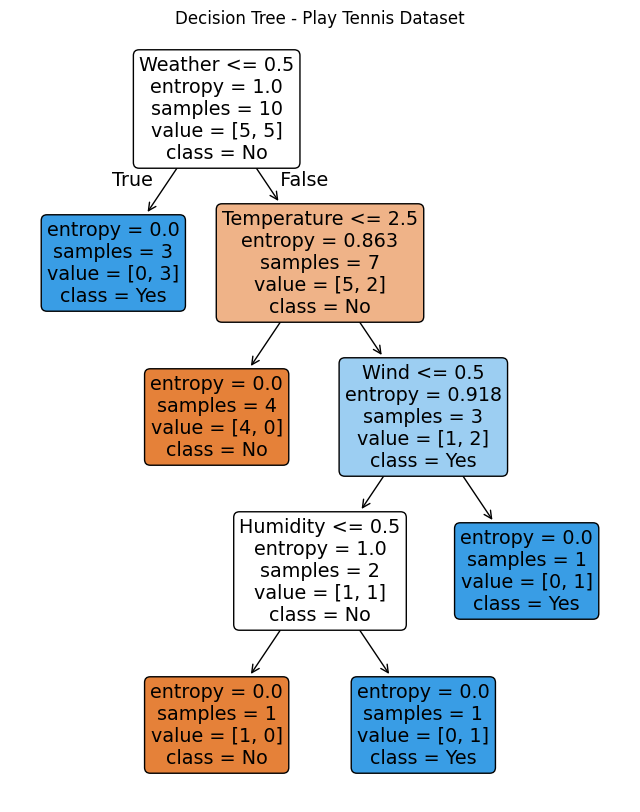

In [114]:
plt.figure(figsize=(8,10))

plot_tree(
  model,
  feature_names=x.columns,
  class_names=['No', 'Yes'],
  filled=True,
  rounded=True
)

plt.title("Decision Tree - Play Tennis Dataset")
plt.show()

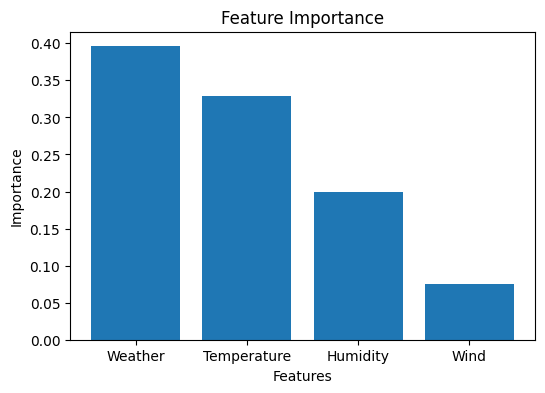

In [115]:
plt.figure(figsize=(6,4))

plt.bar(
  x.columns,
  model.feature_importances_
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [116]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x)

accuracy = accuracy_score(y, y_pred)

print("Accuracy =", accuracy*100,"%")

Accuracy = 100.0 %
